# Evaluating Model Performance

In [1]:
# IMPORT LIBRARIES AND CONFIGURE PATHS
# Core scientific computing libraries for data analysis
import numpy as np          # Numerical operations and array handling
import scipy as sc          #
# Scientific computing functions (filtering, etc.)
import pandas as pd         # Data manipulation and analysis
from sklearn.metrics import matthews_corrcoef, roc_auc_score
from sklearn.model_selection import KFold
import statsmodels.formula.api as smf


# Visualization library
import matplotlib.pyplot as plt  # Plotting and figure generation
import seaborn as sns

# System and file handling utilities
from os.path import join as ospj  # Cross-platform path joining
# from utils import *               # Custom utility functions

# Load configuration paths and settings
from config import Config
# Extract key paths: raw data, processed data, metadata, figures, and patient IDs
datapath, prodatapath, metapath, figpath, rid_hup = Config.deal(['datapath','prodatapath','metapath','figpath','rid_hup'])

## NDD heritage

In [391]:
ndd_old = pd.read_csv(ospj(prodatapath,'res_series_list_ndd.csv'))

FileNotFoundError: [Errno 2] No such file or directory: '/Users/wojemann/local_data/dynasd_data/PROCESSED_DATA/res_series_list_ndd.csv'

<Axes: xlabel='hidden_size', ylabel='test_r2'>

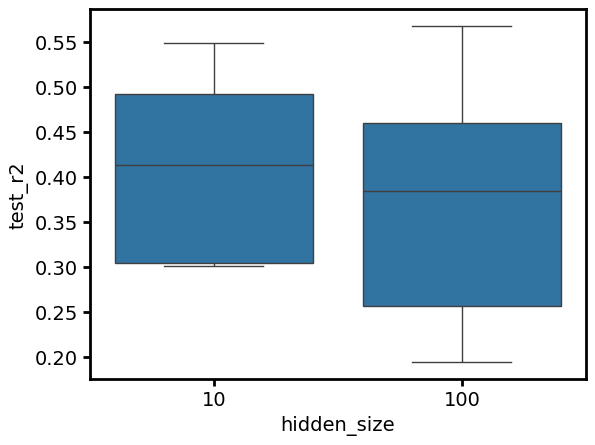

In [ ]:
sns.boxplot(ndd_old[ndd_old['duration']==60],x='hidden_size',y='test_r2')

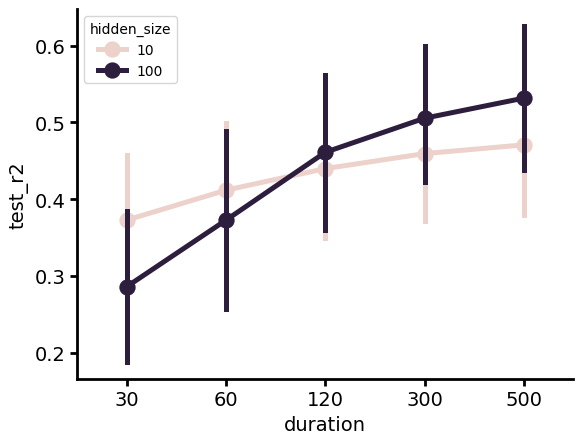

In [ ]:
sns.pointplot(x='duration',hue='hidden_size',y='test_r2',data=ndd_old[ndd_old['forecast_length']==1],legend=True)
sns.despine()

## MINDD hyperparameter optimization

In [ ]:
mindd_results = pd.read_csv(ospj(prodatapath, 'compiled_mindd_optimization_results.csv'))
mindd_results = mindd_results[(mindd_results['patient'] == 'HUP276')]
mindd_results = mindd_results[mindd_results.apply(lambda x: int(x.hidden_sizes.split(',')[0].replace(']','').replace('[','').split(' ')[0]) > x.n_channels*x.sequence_length*0.2,axis=1)]
top10 = mindd_results.nlargest(20, 'test_r2')
print(top10[['test_r2', 'train_r2','val_r2', 'hidden_sizes', 'weights','sequence_length']])

best_row = mindd_results.loc[mindd_results['test_r2'].idxmax()]
best_weights = best_row['weights']
print(f"Best test_r2: {best_row['test_r2']:.4f} with weights={best_weights}")

      test_r2  train_r2    val_r2   hidden_sizes     weights  sequence_length
838  0.846805  0.965526  0.903373  [23808, 3571]    (2, 0.3)              128
363  0.845000  0.958604  0.898688         [9523]      (0.8,)              128
350  0.841300  0.963947  0.899778   [9523, 3571]  (0.8, 0.3)              128
482  0.838377  0.955403  0.894399  [23808, 5952]    (2, 0.5)              128
146  0.836983  0.947585  0.888647         [5952]        (1,)               64
686  0.836541  0.951603  0.890698         [5952]      (0.5,)              128
274  0.826928  0.943451  0.882598        [11904]        (1,)              128
644  0.825952  0.941971  0.880302         [3571]      (0.3,)              128
411  0.824927  0.933344  0.875037         [4761]      (0.8,)               64
259  0.814732  0.938007  0.873368   [5952, 5952]  (0.5, 0.5)              128
816  0.814342  0.937076  0.872548   [5952, 9523]  (0.5, 0.8)              128
545  0.814245  0.933374  0.871234  [11904, 5952]    (1, 0.5)    

In [ ]:
mindd_results = pd.read_csv(ospj(prodatapath, 'compiled_mindd_optimization_results.csv'))
mindd_results = mindd_results[(mindd_results['patient'] == 'HUP065')]
mindd_results = mindd_results[mindd_results.apply(lambda x: int(x.hidden_sizes.split(',')[0].replace(']','').replace('[','').split(' ')[0]) > x.n_channels*x.sequence_length*0.3,axis=1)]
top10 = mindd_results.nlargest(20, 'test_r2')
print(top10[['test_r2', 'train_r2','val_r2', 'hidden_sizes', 'weights','sequence_length']])

best_row = mindd_results.loc[mindd_results['test_r2'].idxmax()]
best_weights = best_row['weights']
print(f"Best test_r2: {best_row['test_r2']:.4f} with weights={best_weights}")

      test_r2  train_r2    val_r2  hidden_sizes     weights  sequence_length
534  0.858744  0.902651  0.894761   [2816, 422]    (2, 0.3)              128
788  0.840073  0.860177  0.874863   [2816, 704]    (2, 0.5)              128
844  0.831381  0.816321  0.866048  [1126, 2816]    (0.8, 2)              128
23   0.828822  0.808358  0.860316  [1126, 1126]  (0.8, 0.8)              128
20   0.828103  0.803983  0.860048  [1126, 1408]    (0.8, 1)              128
228  0.824571  0.816775  0.857192  [2816, 1126]    (2, 0.8)              128
746  0.817343  0.794082  0.846728   [1126, 422]  (0.8, 0.3)              128
715  0.816621  0.786109  0.847647        [2816]        (2,)              128
603  0.816537  0.782077  0.845812   [1126, 704]  (0.8, 0.5)              128
287  0.812146  0.776206  0.843029  [1408, 1126]    (1, 0.8)              128
208  0.809768  0.755488  0.836746        [1408]        (1,)              128
850  0.804837  0.760632  0.834478   [1408, 704]    (1, 0.5)              128

In [ ]:
group_cols = ['sequence_length','weights']
ndd_data_avg = mindd_results.groupby(group_cols, dropna=False, as_index=False)[['train_r2','val_r2','test_r2']].mean()
best_params = []
max_r2 = ndd_data_avg['test_r2'].max()
best = ndd_data_avg[ndd_data_avg['test_r2'] == max_r2]
best_params.append(best)
if best_params:
    best_params_df = pd.concat(best_params, ignore_index=True)
    display(best_params_df.sort_values(['sequence_length']))
else:
    print("No best params found.")
    best_params_df = pd.DataFrame()

,sequence_length,weights,train_r2,val_r2,test_r2
0,128,"(2, 0.3)",0.902651,0.894761,0.858744


## NDD System Identification

In [ ]:
# ndd_data = pd.read_csv(ospj(prodatapath,'res_series_list_deep.csv'))
# ndd_data['model'] = ndd_data['model'].apply(lambda x: x.split('.')[-1][:-2])

In [ ]:
ndd_data = pd.read_csv(ospj(prodatapath,'compiled_ndd_optimization_results.csv'))
# ndd_data = ndd_data[ndd_data['patient']=='HUP065']
gin_data = ndd_data[ndd_data['model']=='GIN']
lin_data = ndd_data[ndd_data['model']=='LiNDDA']
min_data = ndd_data[ndd_data['model']=='MINDD']
lir_data = ndd_data[ndd_data.model=='LiRNDDA']

In [ ]:
ndd_data.patient.nunique()

5

<Axes: xlabel='duration', ylabel='test_r2'>

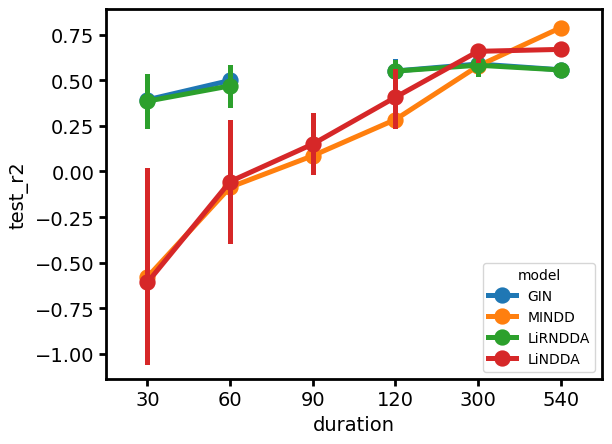

In [ ]:
sns.pointplot(x='duration',hue='model',y='test_r2',data=ndd_data[ndd_data['sequence_length']==128])

In [ ]:
group_cols = ['sequence_length','num_layers','num_stacks']
ndd_data_avg = gin_data[gin_data.duration == 120].groupby(group_cols, dropna=False, as_index=False)[['train_r2','val_r2','test_r2']].mean()
best_params = []
max_r2 = ndd_data_avg['test_r2'].max()
best = ndd_data_avg[ndd_data_avg['test_r2'] == max_r2]
best_params.append(best)
if best_params:
    best_params_df = pd.concat(best_params, ignore_index=True)
    display(best_params_df.sort_values(['sequence_length']))
else:
    print("No best params found.")
    best_params_df = pd.DataFrame()

,sequence_length,num_layers,num_stacks,train_r2,val_r2,test_r2
0,32,1.0,1.0,0.455521,0.53808,0.574985


<Axes: xlabel='sequence_length', ylabel='test_r2'>

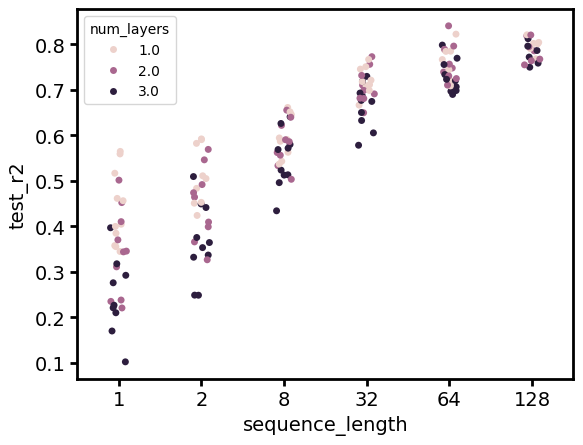

In [ ]:
sns.stripplot(x='sequence_length',y='test_r2',hue='num_layers',data=min_data[min_data['duration']==540])

<Axes: xlabel='sequence_length', ylabel='train_s'>

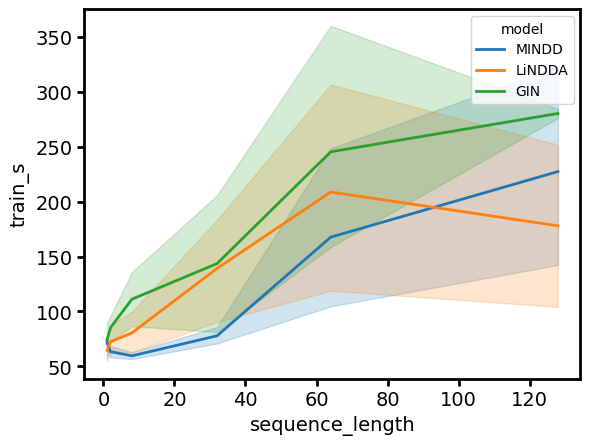

In [ ]:
sns.lineplot(x='sequence_length',hue='model',y='train_s',data=ndd_data[(ndd_data['duration']==540)&(ndd_data.model != 'LiRNDDA')])

<Axes: xlabel='sequence_length', ylabel='test_r2'>

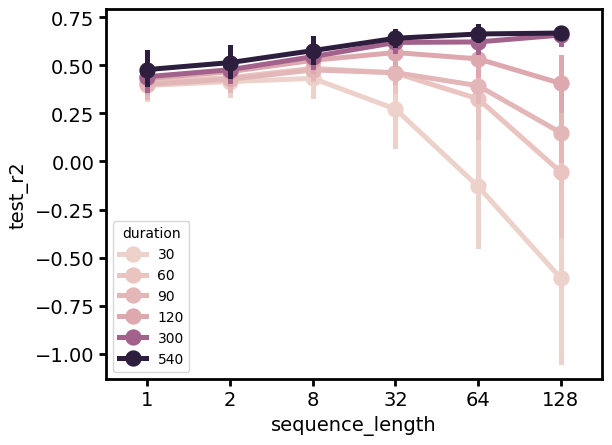

In [ ]:
sns.pointplot(lin_data,x='sequence_length',hue='duration',y='test_r2')

(0.0, 1.0)

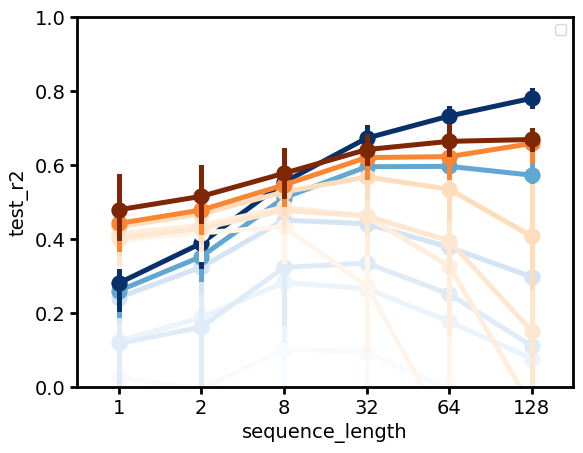

In [ ]:
sns.pointplot(min_data[(min_data['param_scale']==1)],x='sequence_length',y='test_r2',hue='duration',palette='Blues')
sns.pointplot(lin_data,x='sequence_length',y='test_r2',hue='duration',palette='Oranges')
plt.legend([])
plt.ylim(0,1)

In [ ]:
group_cols = ['model','duration','sequence_length','num_layers','param_scale','num_stacks','forecast_length']
ndd_data_avg = ndd_data.groupby(group_cols, dropna=False, as_index=False)[['train_r2','val_r2','test_r2']].mean()
best_params = []
for model in ndd_data_avg['model'].unique():
    for duration in ndd_data_avg['duration'].unique():
        subset = ndd_data_avg[(ndd_data_avg['model'] == model) & (ndd_data_avg['duration'] == duration)]
        if subset.empty: continue
        max_r2 = subset['test_r2'].max()
        best = subset[subset['test_r2'] == max_r2]
        best_params.append(best)
if best_params:
    best_params_df = pd.concat(best_params, ignore_index=True)
    display(best_params_df.sort_values(['model','duration','sequence_length']))
else:
    print("No best params found.")
    best_params_df = pd.DataFrame()


,model,duration,sequence_length,num_layers,param_scale,num_stacks,forecast_length,train_r2,val_r2,test_r2
0,GIN,30,64,1.0,NaN,1.0,1,0.378659,0.394394,0.409219
1,GIN,60,32,1.0,NaN,1.0,1,0.434224,0.462267,0.507847
2,GIN,120,32,1.0,NaN,1.0,1,0.455521,0.538080,0.574985
3,GIN,300,128,1.0,NaN,1.0,1,0.469911,0.551114,0.588645
4,GIN,540,32,1.0,NaN,1.0,1,0.471488,0.606583,0.608054
5,LiNDDA,30,8,NaN,NaN,NaN,1,0.434550,0.504924,0.432667
6,LiNDDA,60,8,NaN,NaN,NaN,1,0.431026,0.511783,0.484901
10,LiNDDA,90,8,NaN,NaN,NaN,1,0.425589,0.504898,0.476701
7,LiNDDA,120,32,NaN,NaN,NaN,1,0.527712,0.622853,0.567271
8,LiNDDA,300,128,NaN,NaN,NaN,1,0.630197,0.677594,0.657976


<Axes: xlabel='sequence_length', ylabel='test_r2'>

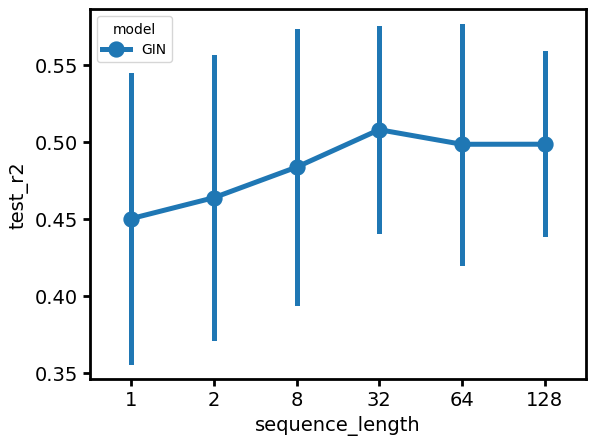

In [ ]:
sns.pointplot(x='sequence_length',hue='model',y='test_r2',data=gin_data[(gin_data['duration']==60)])

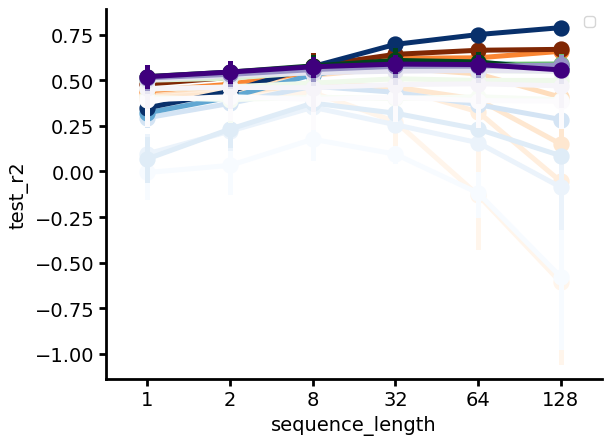

In [ ]:
sns.pointplot(x='sequence_length',hue='duration',y='test_r2',data=lin_data[lin_data['forecast_length']==1],palette='Oranges')
sns.pointplot(x='sequence_length',hue='duration',y='test_r2',data=min_data[min_data['forecast_length']==1],palette='Blues')
sns.pointplot(x='sequence_length',hue='duration',y='test_r2',data=gin_data[gin_data['forecast_length']==1],palette='Greens')
sns.pointplot(x='sequence_length',hue='duration',y='test_r2',data=lir_data[lir_data['forecast_length']==1],palette='Purples')
plt.legend([])
sns.despine()

<Axes: xlabel='model', ylabel='train_s'>

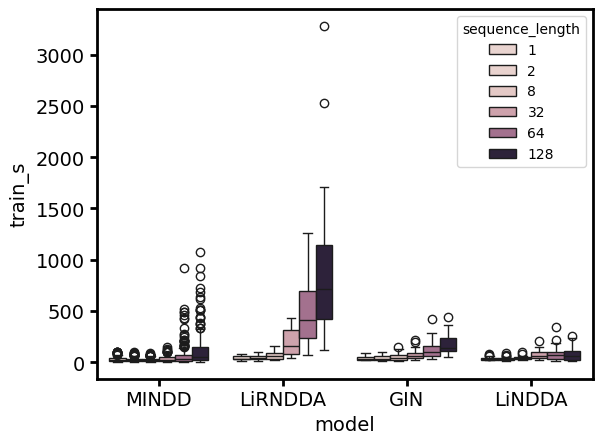

In [ ]:
sns.boxplot(x='model',hue='sequence_length',y='train_s',data=ndd_data)

## Validation performance

In [627]:
shallow_data = pd.read_csv(ospj(prodatapath, "benchmark_model_validation_results.csv"))
shallow_melted = pd.melt(shallow_data, id_vars=['model'], value_vars=['auc','iou_f1','iou_phi','iou_sensitivity','iou_specificity','iou_precision','iou_recall','f1_f1','f1_phi','f1_sensitivity','f1_specificity','f1_precision','f1_recall'], var_name='metric', value_name='value')

In [628]:
shallow_data.columns

Index(['patient', 'onset', 'split', 'stim', 'model', 'auc', 'iou_threshold',
       'iou_f1', 'iou_phi', 'iou_sensitivity', 'iou_specificity',
       'iou_precision', 'iou_recall', 'f1_threshold', 'f1_f1', 'f1_phi',
       'f1_sensitivity', 'f1_specificity', 'f1_precision', 'f1_recall',
       'phi_threshold', 'phi_f1', 'phi_phi', 'phi_sensitivity',
       'phi_specificity', 'phi_precision', 'phi_recall'],
      dtype='object')

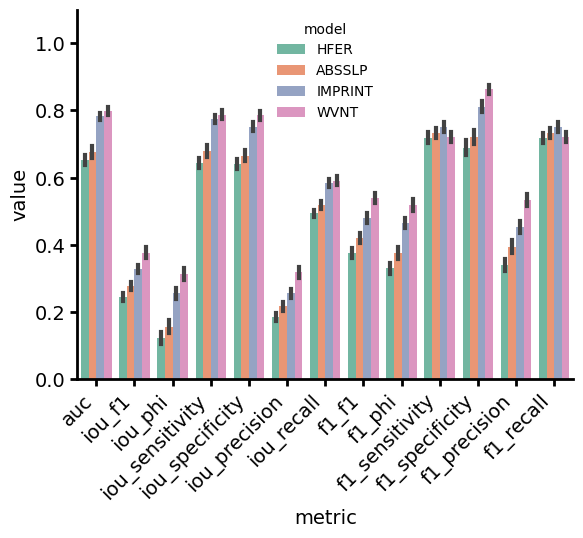

In [629]:
# sns.barplot(x='metric',y='value',hue='model',data=shallow_melted,palette=['purple','blue','green','red'],hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])
sns.barplot(x='metric',y='value',hue='model',data=shallow_melted,palette='Set2',hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])

# sns.stripplot(x='metric',y='value',hue='model',data=shallow_melted, dodge=True, jitter=True,alpha=0.1,color='gray',size=3,legend=False)
plt.ylim([0,1.1])
plt.xticks(rotation=45,ha='right')
sns.despine()

In [630]:
# sns.barplot(x='model',y='threshold',data=shallow_data,palette=['blue','green','red'])
# sns.stripplot(x='model',y='threshold',data=shallow_data, dodge=True, jitter=True,alpha=0.1,color='gray',size=3)
# sns.despine()
iou_benchmark_thresholds = shallow_data.groupby(['model','patient']).agg({'iou_threshold':'median'}).reset_index().groupby('model').agg({'iou_threshold':'median'}).reset_index()
f1_benchmark_thresholds = shallow_data.groupby(['model','patient']).agg({'f1_threshold':'median'}).reset_index().groupby('model').agg({'f1_threshold':'median'}).reset_index()
phi_benchmark_thresholds = shallow_data.groupby(['model','patient']).agg({'phi_threshold':'median'}).reset_index().groupby('model').agg({'phi_threshold':'median'}).reset_index()
print(iou_benchmark_thresholds)
print(f1_benchmark_thresholds)
print(phi_benchmark_thresholds)

     model  iou_threshold
0   ABSSLP     230.419769
1     HFER       9.711496
2  IMPRINT       5.737759
3     WVNT       0.367146
     model  f1_threshold
0   ABSSLP    268.801757
1     HFER     14.238726
2  IMPRINT      7.229341
3     WVNT      0.492918
     model  phi_threshold
0   ABSSLP     279.183993
1     HFER      12.464746
2  IMPRINT       6.950998
3     WVNT       0.494377


In [631]:
f1_benchmark_thresholds.to_csv(ospj(prodatapath,'benchmark_val_thresholds_f1_median.csv'))
iou_benchmark_thresholds.to_csv(ospj(prodatapath,'benchmark_val_thresholds_iou_median.csv'))
phi_benchmark_thresholds.to_csv(ospj(prodatapath,'benchmark_val_thresholds_phi_median.csv'))

## Generalized Validation performance

In [ ]:
val_data = pd.read_csv(ospj(prodatapath, "benchmark_val_analysis_results_f1.csv"))

In [ ]:
val_data.onset.nunique()

1030

In [ ]:
val_data_onset = val_data.melt(id_vars=['patient','model'], value_vars=['sensitivity','specificity','f1','phi'], var_name='metric', value_name='value')
val_data_spread = val_data.melt(id_vars=['patient','model'], value_vars=['med_soz_spread_rank_pct','avg_soz_spread_rank_pct'], var_name='metric', value_name='value')
val_data_latency = val_data.melt(id_vars=['patient','model'], value_vars=['med_soz_recruitment_latency','avg_soz_recruitment_latency'], var_name='metric', value_name='value')

/tmp/ipykernel_37417/4198091649.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:gray'` for the same effect.

  sns.stripplot(x='metric',y='value',hue='model',data=val_data_onset,color='gray',jitter=True,alpha=0.1,legend=False,size=2,dodge=True)


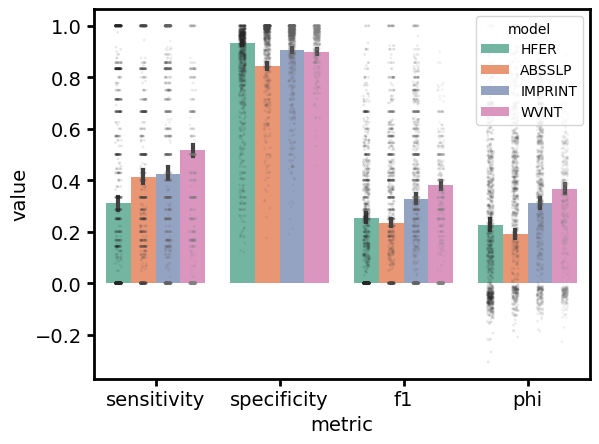

/tmp/ipykernel_37417/4198091649.py:6: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:gray'` for the same effect.

  sns.stripplot(x='metric',y='value',hue='model',data=val_data_spread,color='gray',jitter=True,alpha=0.1,legend=False,size=2,dodge=True)


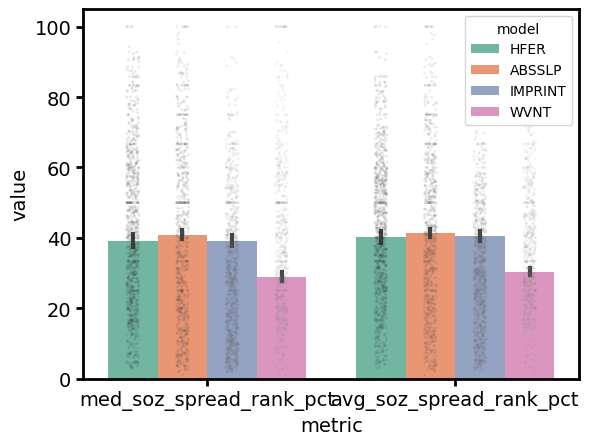

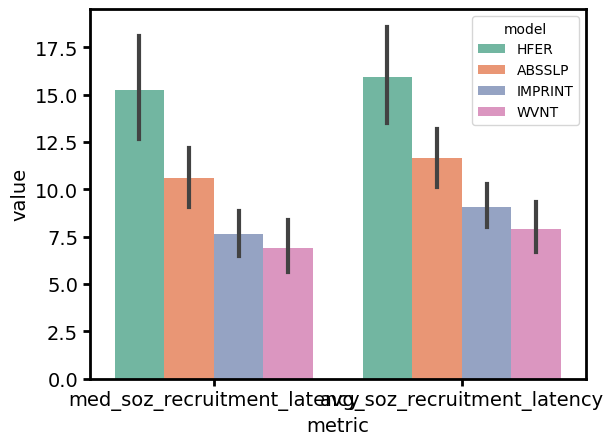

In [ ]:
sns.barplot(x='metric',y='value',hue='model',data=val_data_onset,palette='Set2',hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])
sns.stripplot(x='metric',y='value',hue='model',data=val_data_onset,color='gray',jitter=True,alpha=0.1,legend=False,size=2,dodge=True)
plt.show()

sns.barplot(x='metric',y='value',hue='model',data=val_data_spread,palette='Set2',hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])
sns.stripplot(x='metric',y='value',hue='model',data=val_data_spread,color='gray',jitter=True,alpha=0.1,legend=False,size=2,dodge=True)
plt.show()

sns.barplot(x='metric',y='value',hue='model',data=val_data_latency,palette='Set2',hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])
# sns.stripplot(x='metric',y='value',hue='model',data=val_data_latency,color='gray',jitter=True,alpha=0.1,legend=False,size=2,dodge=True)
plt.show()

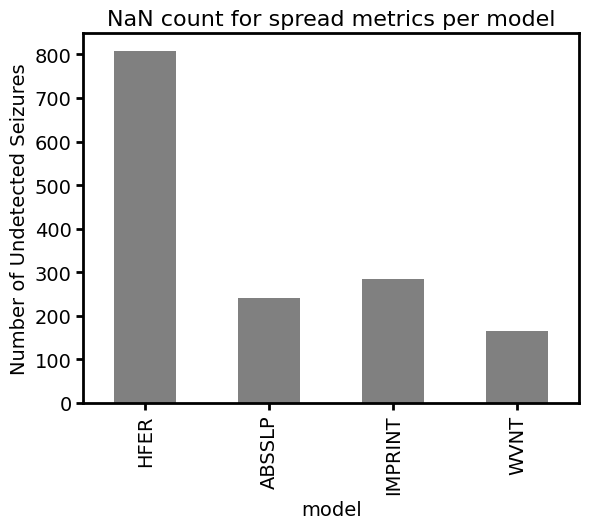

In [ ]:
spread_nan_counts = val_data_spread[val_data_spread['value'].isna()].groupby('model').size()
spread_nan_counts = spread_nan_counts.reindex(['HFER','ABSSLP','IMPRINT','WVNT']).fillna(0)
spread_nan_counts.plot(kind='bar',color='gray')
plt.ylabel('Number of Undetected Seizures')
plt.title('NaN count for spread metrics per model')
plt.show()


## NDD performance

Initial rows: 17343

Metadata duplicates on 'onset': 6
Metadata duplicates on ['patient','onset']: 0
After first merge: 17343 rows

Total duplicate rows: 0

After deduplication: 17343 rows
model
GIN_mse_sl12_fl1      0.833575
LiNDDA_mse_sl3_fl2    0.851321
LiNDDA_mse_sl5_fl4    0.859109
Name: auc, dtype: float64


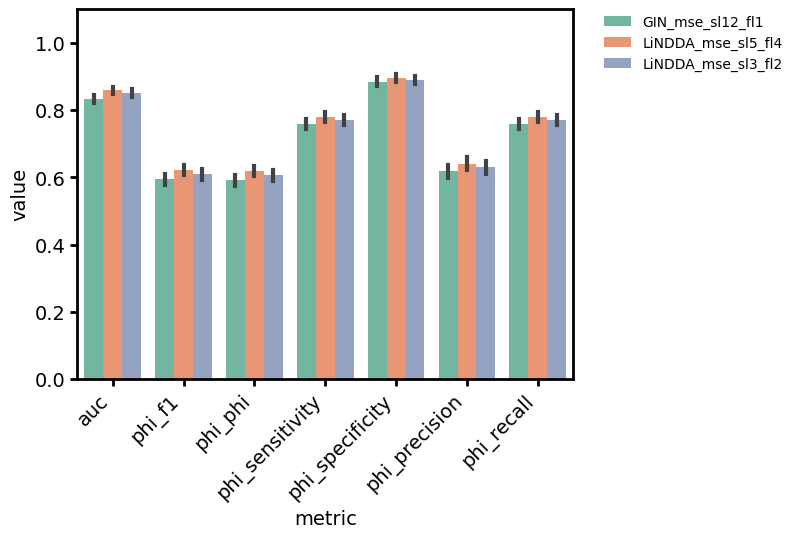

In [836]:
# ndd_data = pd.read_csv(ospj(prodatapath, 'ndd_model_validation_results.csv'))
# ndd_data_latter = pd.read_csv(ospj(prodatapath, 'ndd_model_validation_results_latter.csv'))
# ndd_data_lat_server = pd.read_csv(ospj(prodatapath, 'ndd_model_validation_results_latter_server.csv'))

# ndd_data = pd.concat([ndd_data,ndd_data_latter,ndd_data_lat_server])
# ndd_data_32 = pd.read_csv(ospj(prodatapath, 'ndd_model_validation_results_seq32.csv'))
# ndd_data_32s = pd.read_csv(ospj(prodatapath, 'ndd_model_validation_results_seq32_server.csv'))
# ndd_data = pd.concat([ndd_data,ndd_data_32,ndd_data_32s])
# ndd_data = pd.read_csv(ospj(prodatapath,'ndd_model_validation_results_100.csv'))
# mindd_data = pd.read_csv(ospj(prodatapath,f"mindd_model_validation_results_100.csv"))
# ndd_data = pd.concat([ndd_data,mindd_data])
ndd_data = pd.read_csv(ospj(prodatapath,'ndd_model_validation_results_v4.csv'))
# ndd_data_temp = pd.read_csv(ospj(prodatapath,'ndd_model_validation_results_v2_linddaseq.csv'))
# ndd_data = pd.concat([ndd_data,ndd_data_temp])
print(f"Initial rows: {len(ndd_data)}")

metadata = pd.read_csv(ospj(metapath,'metadata_v7_BIDS.csv'))
metadata['patient'] = metadata['Patient']
metadata['stim'] = metadata['stim'].fillna(0)
metadata['onset'] = metadata['onset'].astype(int)

print(f"\nMetadata duplicates on 'onset': {metadata['onset'].duplicated().sum()}")
print(f"Metadata duplicates on ['patient','onset']: {metadata[['patient','onset']].duplicated().sum()}")

# First merge
ndd_data = ndd_data.merge(metadata[['patient', 'onset', 'stim']], on=['patient', 'onset'], how='left')
print(f"After first merge: {len(ndd_data)} rows")

# Check for duplicates (excluding stim column)
key_cols = [col for col in ndd_data.columns if col != 'stim']
duplicates_mask = ndd_data.duplicated(subset=key_cols, keep=False)
print(f"\nTotal duplicate rows: {duplicates_mask.sum()}")

if duplicates_mask.sum() > 0:
    print("\nPatients/seizures with duplicate rows:")
    dup_patients_onsets = ndd_data[duplicates_mask][['patient','onset']].drop_duplicates().sort_values(['patient','onset'])
    print(f"Total unique patient/onset combos with duplicates: {len(dup_patients_onsets)}")
    display(dup_patients_onsets)
    
    print("\nSample of duplicate rows:")
    display(ndd_data[duplicates_mask].sort_values(['patient','onset','model']).head(20))
    
    # Show what columns vary in duplicates
    print("\nColumns that vary in duplicate groups:")
    dup_subset = ndd_data[duplicates_mask]
    for col in ndd_data.columns:
        n_unique_per_group = dup_subset.groupby(key_cols)[col].nunique()
        if (n_unique_per_group > 1).any():
            print(f"  {col}: varies")

# Handle duplicates by taking max stim value
ndd_data = ndd_data.sort_values('stim', ascending=False).drop_duplicates(subset=key_cols, keep='first')
print(f"\nAfter deduplication: {len(ndd_data)} rows")

ndd_data = ndd_data[ndd_data.split == 1]
ndd_data.loc[ndd_data.model.apply(lambda x: 'onset' in x),'model'] = ndd_data.loc[ndd_data.model.apply(lambda x: 'onset' in x),'model'].apply(lambda x: x.replace('onset_',''))
ndd_data['model'] = ndd_data['model'].astype(str) + '_sl' + ndd_data['sequence'].astype(str) + '_fl' + ndd_data['forecast'].astype(str)
ndd_data = ndd_data[ndd_data.model.apply(lambda x: '_mse_z' not in x)] # ('_mse_s' in x) ('prob_s' in x) and ('fl16' not in x) ('_mse_s' in x) and  ('LiN' in x) and ('LiN' not in x) andand ('_mse_s' in x))
# value_vars = ['auc','iou_f1','iou_phi','iou_sensitivity','iou_specificity','iou_precision','iou_recall']
value_vars = ['auc','phi_f1','phi_phi','phi_sensitivity','phi_specificity','phi_precision','phi_recall']
# value_vars = ['auc','f1_f1','f1_phi','f1_sensitivity','f1_specificity','f1_precision','f1_recall']
ndd_melted = pd.melt(ndd_data, id_vars=['model'], value_vars=value_vars, var_name='metric', value_name='value')

print(ndd_data.groupby('model').auc.mean())

sns.barplot(x='metric',y='value',hue='model',data=ndd_melted,palette='Set2',estimator=np.mean)
plt.ylim([0,1.1])
plt.xticks(rotation=45,ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

In [837]:
ndd_data.onset.nunique()
ndd_data_val = ndd_data.copy()

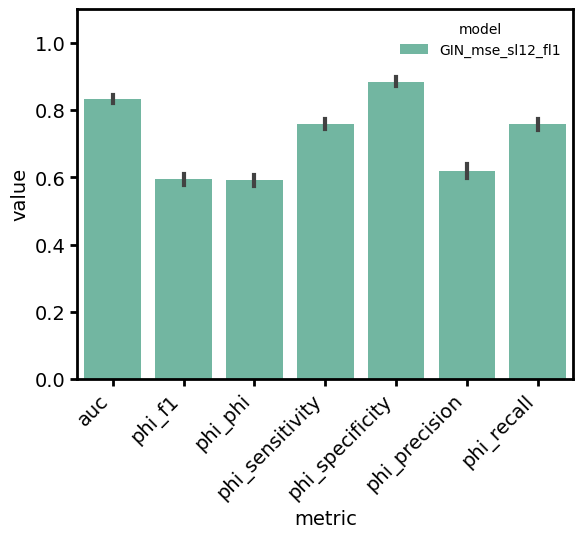

In [838]:
metric_data = ndd_melted[ndd_melted.model.apply(lambda x: ('GIN' in x) and ('fl16' not in x) and ('sl12' in x))] #  ('prob_s' in x) and ('fl16' not in x) ('_mse_s' in x) and  ('LiN' in x) and ('LiN' not in x) andand ('_mse_s' in x))
sns.barplot(x='metric',y='value',hue='model',data=metric_data,palette='Set2')
plt.ylim([0,1.1])
plt.xticks(rotation=45,ha='right')
# plt.legend(loc='upper left')
plt.show()

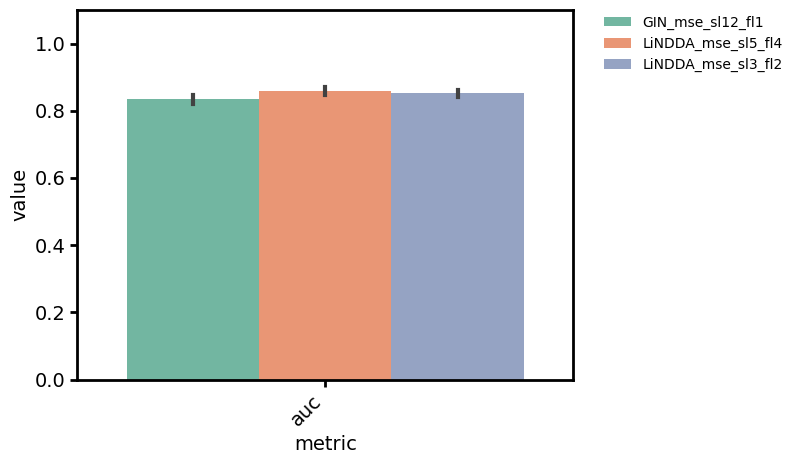

In [839]:
metric_data = ndd_melted[ndd_melted.model.apply(lambda x: (('GIN' in x) or ('LiN' in x) or ('MINDD' in x)) and ('fl16' not in x) and (('_mse_s' in x) or ('_prob' in x)))]
metric_data = metric_data[metric_data.metric == 'auc'] # and ('sl12' in x) ('prob_s' in x) and ('fl16' not in x)  and  ('LiN' in x) and ('LiN' not in x) andand ('_mse_s' in x))
sns.barplot(x='metric',y='value',hue='model',data=metric_data,palette='Set2')
plt.ylim([0,1.1])
plt.xticks(rotation=45,ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

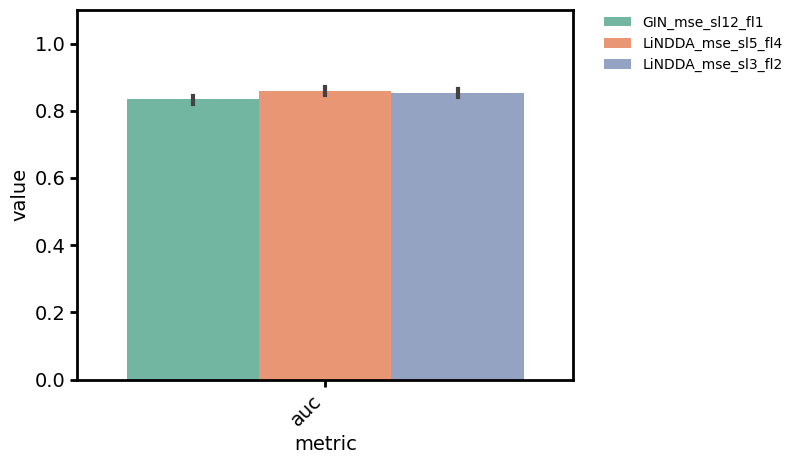

In [840]:
metric_data = ndd_melted[ndd_melted.model.apply(lambda x: (('GIN' in x) or ('LiN' in x) or ('MINDD' in x)) and (('_mse_s' in x)))]
metric_data = metric_data[metric_data.metric == 'auc'] # and ('sl12' in x) ('prob_s' in x) and ('fl16' not in x)  and  ('LiN' in x) and ('LiN' not in x) andand ('_mse_s' in x))
sns.barplot(x='metric',y='value',hue='model',data=metric_data,palette='Set2')
plt.ylim([0,1.1])
plt.xticks(rotation=45,ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

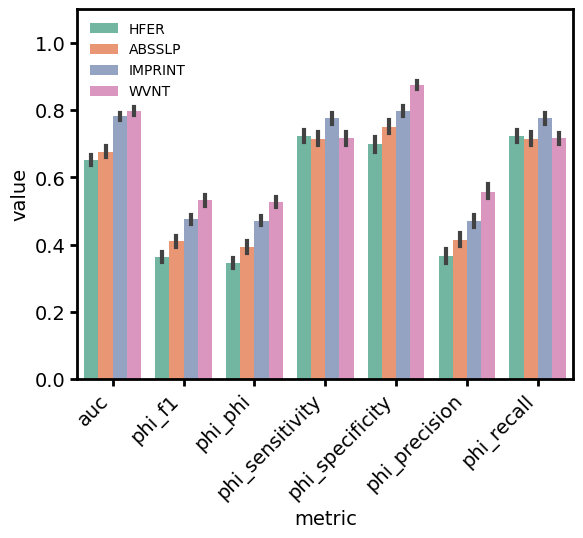

In [841]:
benchmark_data = pd.read_csv(ospj(prodatapath, 'benchmark_model_validation_results.csv'))
benchmark_data = benchmark_data[benchmark_data.onset.isin(ndd_data.onset)]
benchmark_melted = benchmark_data.melt(id_vars=['model'], value_vars=value_vars, var_name='metric', value_name='value')

sns.barplot(x='metric',y='value',hue='model',data=benchmark_melted,palette='Set2',hue_order=['HFER','ABSSLP','IMPRINT','WVNT'])
plt.ylim([0,1.1])
plt.xticks(rotation=45,ha='right')
plt.legend(loc='upper left')
plt.show()

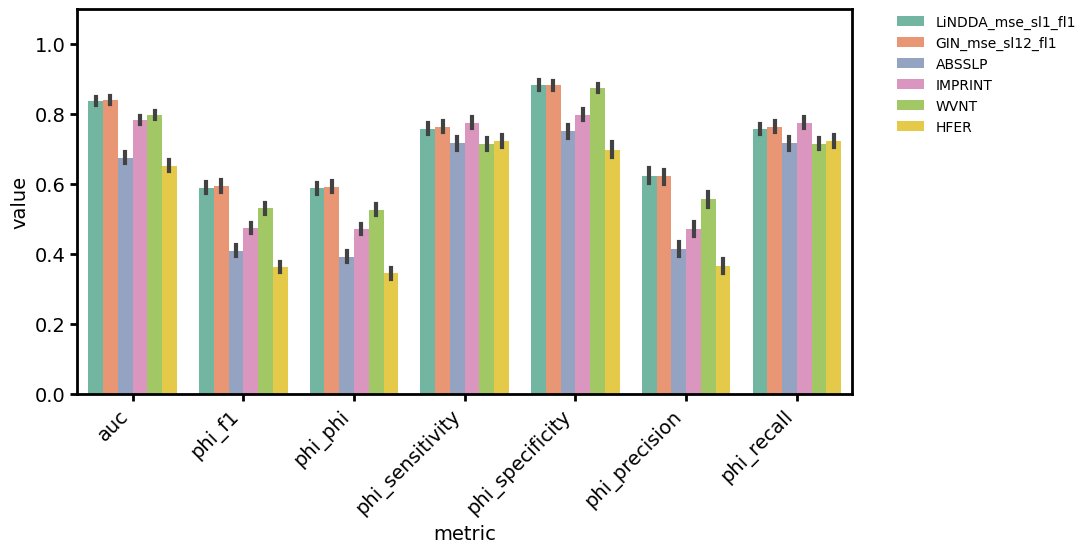

In [719]:
all_data = pd.concat([ndd_melted,benchmark_melted],axis=0).reset_index(drop=True)
fig,ax = plt.subplots(figsize=(10,5))
sns.barplot(x='metric',y='value',hue='model',data=all_data,palette='Set2',estimator=np.mean)
plt.ylim([0,1.1])
plt.xticks(rotation=45,ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.show()

In [671]:
# Find the model with the highest average performance for each metric
best_models_per_metric = all_data.groupby(['metric', 'model'])['value'].mean().reset_index()
top3_models = best_models_per_metric.groupby('metric').apply(lambda x: x.nlargest(5, 'value')).reset_index(drop=True)
print("Top 3 models for each metric:")
print(top3_models)

Top 3 models for each metric:
             metric               model     value
0               auc    GIN_mse_sl12_fl1  0.840111
1               auc  LiNDDA_mse_sl1_fl1  0.837128
2               auc                WVNT  0.798511
3               auc             IMPRINT  0.782151
4               auc              ABSSLP  0.675744
5            phi_f1    GIN_mse_sl12_fl1  0.593633
6            phi_f1  LiNDDA_mse_sl1_fl1  0.589641
7            phi_f1                WVNT  0.531351
8            phi_f1             IMPRINT  0.475052
9            phi_f1              ABSSLP  0.409542
10          phi_phi    GIN_mse_sl12_fl1  0.591540
11          phi_phi  LiNDDA_mse_sl1_fl1  0.588896
12          phi_phi                WVNT  0.527069
13          phi_phi             IMPRINT  0.471625
14          phi_phi              ABSSLP  0.392893
15    phi_precision  LiNDDA_mse_sl1_fl1  0.623855
16    phi_precision    GIN_mse_sl12_fl1  0.621693
17    phi_precision                WVNT  0.557631
18    phi_precision 

/var/folders/9k/4csk57xn1q1csdw28xvkxm200000gn/T/ipykernel_61709/633319701.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top3_models = best_models_per_metric.groupby('metric').apply(lambda x: x.nlargest(5, 'value')).reset_index(drop=True)


In [674]:
iou_ndd_thresholds = ndd_data.groupby(['model','patient']).agg({'iou_threshold':'mean'}).reset_index().groupby('model').agg({'iou_threshold':'mean'}).reset_index()
f1_ndd_thresholds = ndd_data.groupby(['model','patient']).agg({'f1_threshold':'mean'}).reset_index().groupby('model').agg({'f1_threshold':'mean'}).reset_index()
phi_ndd_thresholds = ndd_data.groupby(['model','patient']).agg({'phi_threshold':'mean'}).reset_index().groupby('model').agg({'phi_threshold':'mean'}).reset_index()
print(iou_ndd_thresholds)
print(f1_ndd_thresholds)
print(phi_ndd_thresholds)

                model  iou_threshold
0    GIN_mse_sl12_fl1       0.913875
1  LiNDDA_mse_sl1_fl1       0.898001
                model  f1_threshold
0    GIN_mse_sl12_fl1      0.948297
1  LiNDDA_mse_sl1_fl1      0.939776
                model  phi_threshold
0    GIN_mse_sl12_fl1       0.947901
1  LiNDDA_mse_sl1_fl1       0.940923


In [675]:
f1_ndd_thresholds.to_csv(ospj(prodatapath,'ndd_val_thresholds_f1_v2.csv'))
iou_ndd_thresholds.to_csv(ospj(prodatapath,'ndd_val_thresholds_iou_v2.csv'))
phi_ndd_thresholds.to_csv(ospj(prodatapath,'ndd_val_thresholds_phi_v2.csv'))

## NDD generalization performance

In [2]:
thresh_key = 'phi'
benchmark_val = pd.read_csv(ospj(prodatapath, f"benchmark_val_analysis_results_{thresh_key}_v3.csv"))
ndd_val = pd.read_csv(ospj(prodatapath, f"ndd_spread_analysis_results_{thresh_key}_v3.csv"), on_bad_lines='warn')
ndd_val = ndd_val[ndd_val.aggregation == 'median']

ndd_val = ndd_val[(ndd_val.model.apply(lambda x: (('GIN' in x) or ('LiN' in x)) and (('_mse_s' in x)) and  ('fl16' not in x))) & (ndd_val.model_name.apply(lambda x: 'tau' not in x))]
# (('sl1' in x) or ('sl12' in x)) and
mdl_map = {'LiNDDA_mse_sl5_fl4':'LiNDDA','GIN_mse_sl12_fl1nopass_nolayernorm':'NDD'}
ndd_val['model'] = ndd_val['model'].map(mdl_map)
benchmark_val = benchmark_val[benchmark_val.onset.isin(ndd_val.onset)]
all_val = pd.concat([benchmark_val,ndd_val])
na_list = ['f1','phi','sensitivity','specificity','precision','recall']
all_val[na_list] = all_val[na_list].fillna(0)
print(all_val.onset.nunique())
print(all_val.patient.nunique())
avg_seizures_per_patient = all_val.groupby('patient').onset.nunique()
print("Average seizures per patient:", avg_seizures_per_patient.mean())
print("Std seizures per patient:", avg_seizures_per_patient.std())
# all_val = ndd_val
all_val_melted = pd.melt(all_val, id_vars=['model'], value_vars=['auc','f1','phi','sensitivity','specificity','precision'], var_name='metric', value_name='value')
# all_val.groupby(['model','aggregation'],as_index=False)['f1'].apply(lambda x: np.nanmean(x))

1039
107
Average seizures per patient: 9.728971962616823
Std seizures per patient: 17.30065441747194


In [3]:
hue_order = ['HFER','ABSSLP','IMPRINT','WVNT','NDD','LiNDDA']
color_palette = ['#377eb8','#4daf4a','#984ea3','#e41a1c','#a65628','#ff7f00']
# color_palette = ['#f5ecdc', '#c4d5a7', '#7dbc95', '#469c9c', '#665b7f', '#4fc3e6', '#5673b6']
# color_palette = ['#ffe78e', '#b8db7d', '#60ccc8', '#379cac', '#38598c', '#2c2251', '#2d1737']
# color_palette = ['#fcfdbf', '#daea6f', '#a8c96a', '#74a268', '#447484', '#38598c', '#00202c']
# color_palette = ['#f6e8aa', '#b1e47d', '#57c899', '#4398b9', '#665b7f', '#423c76', '#372944']

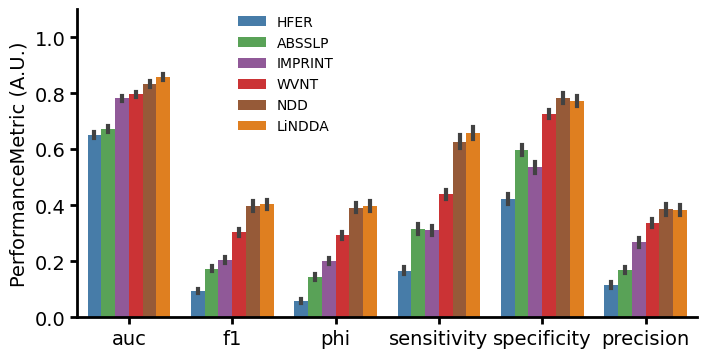

In [962]:
plt.figure(figsize=(8,4))
sns.barplot(x='metric',y='value',hue='model',data=all_val_melted,
estimator=np.mean,
palette=color_palette,
hue_order=hue_order,
gap=0.0
)
# sns.stripplot(x='metric',y='value',hue='model',data=all_val_melted,
# palette = ['grey','grey','grey','grey','grey','grey'],
# size=1,
# alpha=0.2,
# legend=False,
# dodge=True
# )
plt.legend(loc='upper left', bbox_to_anchor=(0.25, 1), borderaxespad=0.)
plt.ylim([0,1.1])
plt.xlabel('')
plt.ylabel('PerformanceMetric (A.U.)')
sns.despine()
plt.show()


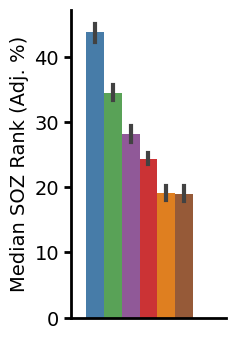

In [ ]:
spread_val_melted = pd.melt(all_val, id_vars=['model'], value_vars=['adj_med_soz_spread_rank_pct'], var_name='metric', value_name='value')
plt.figure(figsize=(2,4))
sns.barplot(x='metric',y='value',hue='model',data=spread_val_melted,
palette=color_palette,
hue_order=hue_order,
gap=0.0,
legend=False
)

# plt.legend(bbox_to_anchor=(0.795, 1), loc='upper left', borderaxespad=0.)
plt.xlabel('')
plt.xticks([])
plt.ylabel('Median SOZ Rank (Adj. %)')

sns.despine()

In [1000]:
import statsmodels.formula.api as smf
all_validation_stats = []
for result_key in ['auc','f1','phi','specificity','precision','recall','sensitivity','avg_soz_recruitment_latency','adj_med_soz_spread_rank_pct']:
    for key1,key2 in zip(['NDD'] * 4 + ['LiNDDA'] * 4,['HFER','ABSSLP','IMPRINT','WVNT']*2):
        # Subset to only LiNDDA and interrater entries, drop rows with missing phi values or patient
        lme_data = all_val[
            all_val['model'].isin([key1, key2])
        ].copy()
        lme_data = lme_data[
            lme_data[result_key].notnull() &
            lme_data['patient'].notnull()
        ]

        # Ensure patient is treated as a categorical
        lme_data['patient'] = lme_data['patient'].astype(str)

        # Pivot to wide form: columns = model_name, values = phi_at_optimal_threshold
        pivot = lme_data.pivot_table(
            index=['patient', 'onset'], 
            columns='model', 
            values=result_key
        ).reset_index()

        # Calculate difference: LiNDDA - interrater for each (patient, onset) pair
        pivot = pivot.dropna(subset=[key1, key2])  # drop pairs lacking either value
        pivot['metric_diff'] = pivot[key1] - pivot[key2]

        # Prepare data for modeling
        diff_data = pivot[['patient', 'metric_diff']].copy()

        # Fit the LME model: phi_diff ~ 1 + (1|patient)
        md = smf.mixedlm(
            "metric_diff ~ 1",
            diff_data,
            groups=diff_data["patient"]
        )
        lme_model = md.fit()
        result_dict = {
            'stage': 'validation',
            'model1': key1,
            'model2': key2,
            'metric': result_key,
            'p_value': lme_model.pvalues['Intercept'],
            'intercept': lme_model.params['Intercept']
        }
        all_validation_stats.append(result_dict)
        # print(key1,', ',key2, lme_model.pvalues['Intercept'])
all_validation_stats = pd.DataFrame(all_validation_stats)
    # print(lme_model.summary())
all_validation_stats.head()

/Users/wojemann/Documents/CNT/stim-env/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/wojemann/Documents/CNT/stim-env/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


,stage,model1,model2,metric,p_value,intercept
0,validation,NDD,HFER,auc,1.070119e-13,0.163459
1,validation,NDD,ABSSLP,auc,2.245449e-24,0.154929
2,validation,NDD,IMPRINT,auc,6.613822e-02,0.025125
3,validation,NDD,WVNT,auc,1.511758e-05,0.041159
4,validation,LiNDDA,HFER,auc,9.097811e-19,0.189592


In [999]:
lme_model.params['Intercept']

np.float64(-7.470285945457955)

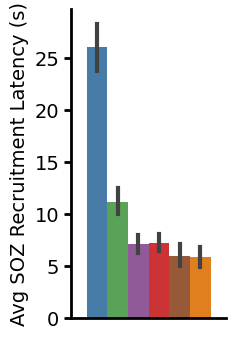

In [944]:
spread_val_melted = pd.melt(all_val, id_vars=['model'], value_vars=['avg_soz_recruitment_latency'], var_name='metric', value_name='value')

plt.figure(figsize=(2,4))
sns.barplot(x='metric',y='value',hue='model',data=spread_val_melted,
estimator=np.mean,
palette=color_palette,
hue_order=hue_order,
gap=0.0,
legend=False
)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.ylabel('Avg SOZ Recruitment Latency (s)')
plt.xlabel('')
plt.xticks([])
sns.despine()
plt.show()

In [972]:
# Find the model with the highest average performance for each metric
best_models_per_metric = all_val_melted.groupby(['metric', 'model'])['value'].mean().reset_index()
top3_models = best_models_per_metric.groupby('metric').apply(lambda x: x.nlargest(5, 'value')).reset_index(drop=True)
# print("Top 3 models for each metric:")
# print(top3_models)

/var/folders/9k/4csk57xn1q1csdw28xvkxm200000gn/T/ipykernel_61709/3748185187.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top3_models = best_models_per_metric.groupby('metric').apply(lambda x: x.nlargest(5, 'value')).reset_index(drop=True)


## Test set performance

In [49]:
# test_data = pd.read_csv(ospj(prodatapath,'test_validation_results.csv'))
test_data = pd.read_pickle(ospj(prodatapath,'test_validation_results_nopass_nolayernorm.pkl'))
# test_data_old = pd.read_pickle(ospj(prodatapath,'test_validation_results.pkl'))
# test_data_old = test_data_old[test_data_old.model_name.apply(lambda x: 'GIN' in x or 'LiNDDA' in x)]
# test_data_old['model_name'] = test_data_old['model_name'].map({'GIN':'NDD121','LiNDDA':'LiNDDA11'})
# test_data = pd.concat([test_data,test_data_old],ignore_index=True)
test_data = test_data[test_data.patient.apply(lambda x: 'HUP' in x)]
test_data = test_data[test_data.stim==0]

# test_data['model_name'] = test_data['model_name'].map({'GIN':'NDD'})
# test_data['model'] = test_data.pop('model_name')
test_data['model_name'] = test_data['model_name'].replace('GIN', 'NDD')
# tau_df = test_data[test_data.model_name.isin(['LiNDDA', 'NDD']) & test_data.onset_phi_at_learned_tau.notna()]
# tau_df['onset_phi_at_learned_phi'] = tau_df['onset_phi_at_learned_tau']
# tau_df['region_onset_phi_at_learned_phi'] = tau_df['region_onset_phi_at_learned_tau']
# tau_df['region_spread_phi_at_learned_phi'] = tau_df['region_spread_phi_at_learned_tau']
# tau_df['spread_phi_at_learned_phi'] = tau_df['spread_phi_at_learned_tau']
# tau_df['model_name'] = tau_df['model_name'].apply(lambda x: f"${x}_\\tau$")
# test_data = pd.concat([test_data, tau_df], ignore_index=True)
hue_order = ['HFER','ABSSLP','IMPRINT','WVNT','NDD','LiNDDA','Interrater']
color_palette = ['#377eb8','#4daf4a','#984ea3','#e41a1c','#ff7f00','#a65628','gray']

In [50]:
test_data.model_name.unique()
# test_data.full_model_key.unique()
# test_data.model_name_full.unique()

array(['LiNDDA', 'NDD', 'ABSSLP', 'IMPRINT', 'WVNT', 'HFER'], dtype=object)

### Logistic NDD

In [51]:
# logistic_results = pd.read_csv(ospj(prodatapath,'ndd_logistic_train_results_all.csv'))
# logistic_results = pd.read_csv(ospj(prodatapath,'ndd_logistic_test_results.csv'))
# logistic_results = logistic_results[logistic_results.patient.apply(lambda x: 'HUP' in x)]

In [7]:
# key = 'test_phi'
# plt.subplots(figsize=(3.5,4))
# plt.ylabel('$\phi$')
# sns.stripplot(logistic_results,x='model',y=key,hue='model',
# palette=['gray']*7,size=3.5,alpha=0.5,zorder=0,
# dodge = 0
# )

# sns.pointplot(logistic_results,x='model',y=key,hue='model',estimator='mean',
# linestyle='none',
# marker='_',
# markersize=20,
# zorder=1,
# dodge = 0,
# )

### LOPO

In [31]:
cval_results = []
n_patients = test_data.patient.nunique()
patients = test_data.patient.unique()
kfold = KFold(n_splits=n_patients-1, shuffle=False)
for model in test_data.model_name.unique():
    model_data = test_data[test_data.model_name == model]
    for train_idx, test_idx in kfold.split(patients):
        train_patients = patients[train_idx]
        test_patients = patients[test_idx]
        data_test = model_data[model_data.patient.isin(test_patients)]
        data_train = model_data[~model_data.patient.isin(test_patients)]
        best_thresholds = []
        best_phis = []
        for _,group in data_train.groupby('patient'):
            best_pt_thresholds = []
            best_pt_phis = []
            for _,row in group.iterrows():
                onset_prob_data = row['onset_prob_data']
                X_train = onset_prob_data.loc['probability',:].values
                y_train = onset_prob_data.loc['label',:].values
                best_phi = -1
                best_threshold = 0
                for t in np.unique(X_train):
                    y_pred = (X_train >= t).astype(int)
                    phi = matthews_corrcoef(y_train,y_pred)
                    if phi > best_phi:
                        best_phi = phi
                        best_threshold = t
                best_pt_thresholds.append(best_threshold)
                best_pt_phis.append(best_phi)
            best_thresholds.append(np.mean(best_pt_thresholds))
            best_phis.append(np.mean(best_pt_phis))
        optimal_threshold = np.mean(best_thresholds)
        test_phis = []
        for _,row in data_test.iterrows():
            onset_prob_data = row['onset_prob_data']
            X_test = onset_prob_data.loc['probability',:].values
            y_test = onset_prob_data.loc['label',:].values
            y_pred = (X_test >= optimal_threshold).astype(int)
            phi = matthews_corrcoef(y_test,y_pred)
            test_phis.append(phi)
            fold_dict = {
                'patient':row['patient'],
                'onset':row['onset'],
                'model':row['model_name'],
                'phi':phi,
                'train_phi':np.mean(best_phis),
                'train_phis':best_phis,
                'train_thresholds':best_thresholds,
                'train_threshold':optimal_threshold
            }
            cval_results.append(fold_dict)
cval_data = pd.DataFrame(cval_results)
cval_data.to_csv(ospj(prodatapath,'test_set_cval_results_2.csv'),index=False)
cval_data = pd.read_csv(ospj(prodatapath,'test_set_cval_results_2.csv'))
print(cval_data)


    patient   onset   model       phi  train_phi  \
0    HUP224  519177  LiNDDA -0.022508   0.658129   
1    HUP224  491467  LiNDDA  0.416510   0.658129   
2    HUP224  339143  LiNDDA  0.440641   0.658129   
3    HUP225  408576  LiNDDA  0.000000   0.658129   
4    HUP225  393496  LiNDDA  0.000000   0.658129   
..      ...     ...     ...       ...        ...   
241  HUP266  253214    HFER -0.014505   0.282337   
242  HUP266  301581    HFER -0.037257   0.282337   
243  HUP267   49987    HFER  0.000000   0.305888   
244  HUP273  233275    HFER -0.043315   0.298207   
245  HUP275  297659    HFER -0.035506   0.302418   

                                            train_phis  \
0    [np.float64(0.3796898951007837), np.float64(0....   
1    [np.float64(0.3796898951007837), np.float64(0....   
2    [np.float64(0.3796898951007837), np.float64(0....   
3    [np.float64(0.3796898951007837), np.float64(0....   
4    [np.float64(0.3796898951007837), np.float64(0....   
..                         

In [ ]:
cval_data['train_thresholds'].iloc[0]
import re

s = '[np.float64(0.9819451236724852), np.float64(1.1684606689214707), np.float64(1.7920645898580552), np.float64(1.4281825476884842), np.float64(1.2712239903211593), np.float64(1.7327134782075881), np.float64(0.7285711777210235), np.float64(0.7490672886371612), np.float64(1.1038282251358034), np.float64(1.6563148647546768), np.float64(1.4012920165061948), np.float64(1.9271627208590507), np.float64(2.3594070565700536), np.float64(0.6410662603378297), np.float64(0.9140871042013169), np.float64(1.0730424210429192)]'

float_list = [float(x) for x in re.findall(r"np\.float64\((.*?)\)", s)]
print(float_list)


'[np.float64(0.9819451236724852), np.float64(1.1684606689214707), np.float64(1.7920645898580552), np.float64(1.4281825476884842), np.float64(1.2712239903211593), np.float64(1.7327134782075881), np.float64(0.7285711777210235), np.float64(0.7490672886371612), np.float64(1.1038282251358034), np.float64(1.6563148647546768), np.float64(1.4012920165061948), np.float64(1.9271627208590507), np.float64(2.3594070565700536), np.float64(0.6410662603378297), np.float64(0.9140871042013169), np.float64(1.0730424210429192)]'

0.9389910385012626


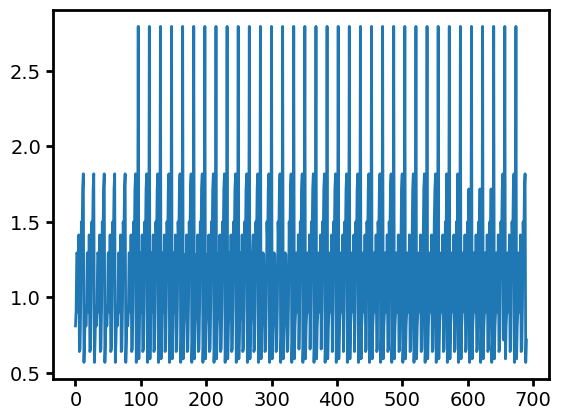

In [30]:
import re
x = []
for i in cval_data[cval_data.model == 'NDD']['train_thresholds']:
    x.extend([float(x) for x in re.findall(r"np\.float64\((.*?)\)", i)])
plt.plot(x)
print(np.median(x))

<Axes: xlabel='model', ylabel='phi'>

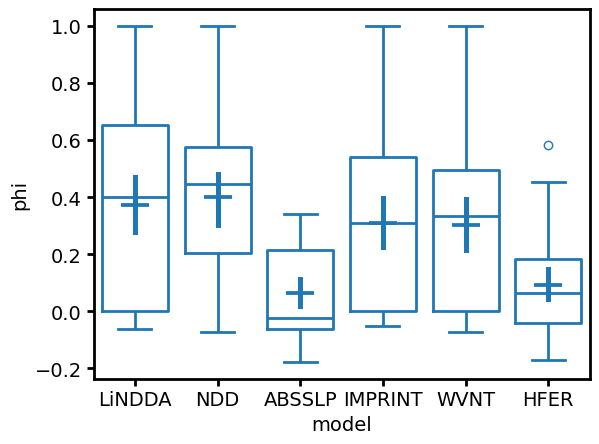

In [26]:
sns.boxplot(cval_data,x='model',y='phi',fill=False)
sns.pointplot(cval_data,x='model',y='phi',estimator='mean',linestyle='none',marker='_',markersize=20,zorder=1,dodge=0)

### Thresholds

In [53]:
cols = list(test_data.columns)

if 'onset_inter_rater_reliability' not in test_data.columns:
    raise ValueError("No column found for onset_inter_rater_reliability value.")

# Get unique patient/onset pairs and their onset_inter_rater_reliability
unique_pairs = test_data[['patient', 'onset', 'stim','onset_inter_rater_reliability','spread_inter_rater_reliability','region_onset_inter_rater_reliability','region_spread_inter_rater_reliability']].drop_duplicates()

# Create a new DataFrame for interrater results
interrater_rows = []
for _, row in unique_pairs.iterrows():
    new_row = {col: None for col in cols}
    new_row['patient'] = row['patient']
    new_row['onset'] = row['onset']
    new_row['stim'] = row['stim']
    new_row['model_name'] = 'Interrater'
    new_row['full_model_key'] = 'Interrater'
    # Put the onset_inter_rater_reliability into phi_at_optimal_threshold
    new_row['max_onset_phi'] = row['onset_inter_rater_reliability']
    # Assign the reliability value to the desired columns
    for colname in ['onset_phi_at_learned_phi', 'onset_phi_at_learned_f1', 'onset_phi_at_learned_iou', 'onset_phi_at_learned_tau']:
        if colname in cols:
            new_row[colname] = row['onset_inter_rater_reliability']
    for colname in ['max_spread_phi', 'spread_phi_at_learned_phi', 'spread_phi_at_learned_f1', 'spread_phi_at_learned_iou', 'spread_phi_at_learned_tau']:
        if colname in cols:
            new_row[colname] = row['spread_inter_rater_reliability']
    for colname in ['region_max_onset_phi', 'region_max_spread_phi', 'region_onset_phi_at_learned_f1', 'region_onset_phi_at_learned_phi', 'region_spread_phi_at_learned_phi', 'region_onset_auc', 'region_onset_phi_at_learned_tau']:
        if colname in cols:
            new_row[colname] = row['region_onset_inter_rater_reliability']
    for colname in ['region_max_spread_phi', 'region_spread_phi_at_learned_phi', 'region_spread_phi_at_learned_f1', 'region_spread_phi_at_learned_iou', 'region_spread_phi_at_learned_tau']:
        if colname in cols:
            new_row[colname] = row['region_spread_inter_rater_reliability']
    interrater_rows.append(new_row)

interrater_df = pd.DataFrame(interrater_rows, columns=cols)
test_data_interrater = pd.concat([test_data, interrater_df], ignore_index=True)

/var/folders/9k/4csk57xn1q1csdw28xvkxm200000gn/T/ipykernel_14463/1351766986.py:36: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  test_data_interrater = pd.concat([test_data, interrater_df], ignore_index=True)


In [10]:
test_data_interrater = test_data_interrater.dropna(subset=['max_onset_phi'])
test_data_interrater.onset.nunique()

41

In [980]:
test_data_interrater[test_data_interrater.full_model_key.isin(['GIN_mse_sl12_fl1'])].max_onset_phi.values.max()

np.float64(1.0)

model_name
ABSSLP        0.498947
HFER          0.460511
IMPRINT       0.752674
Interrater    0.789891
LiNDDA        0.752050
NDD           0.709327
WVNT          0.693594
Name: region_max_onset_phi, dtype: float64
model_name
ABSSLP        0.660454
HFER          0.566735
IMPRINT       0.787061
Interrater    0.753917
LiNDDA        0.804794
NDD           0.794735
WVNT          0.754032
Name: region_max_spread_phi, dtype: float64
model_name
ABSSLP        0.195948
HFER          0.085222
IMPRINT       0.181092
Interrater    0.789891
LiNDDA        0.476598
NDD           0.373024
WVNT          0.265361
Name: region_onset_phi_at_learned_phi, dtype: float64
model_name
ABSSLP        0.333914
HFER          0.197381
IMPRINT       0.354264
Interrater    0.753917
LiNDDA        0.550478
NDD           0.524268
WVNT          0.516552
Name: region_spread_phi_at_learned_phi, dtype: float64


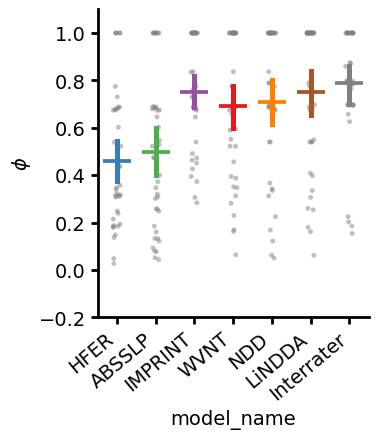

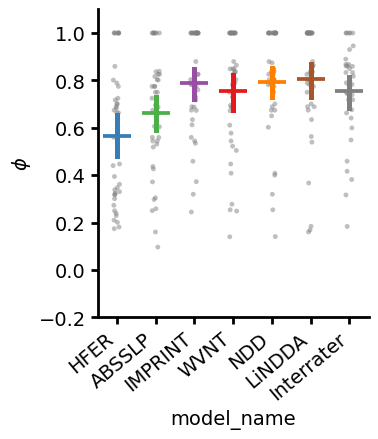

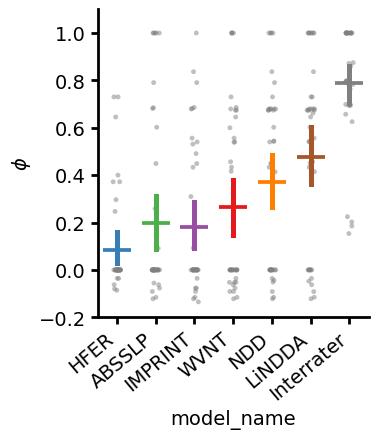

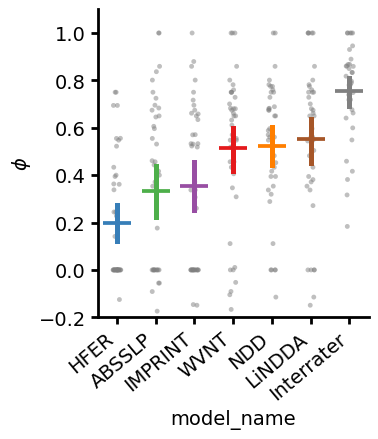

In [56]:
for phi_key in ['max_onset_phi','max_spread_phi','onset_phi_at_learned_phi','spread_phi_at_learned_phi']:

    region = True
    if region:
        phi_key = 'region_'+phi_key

    plt.subplots(figsize=(3.5,4))
    # sns.boxplot(test_data_interrater,x='model_name',y=phi_key,hue='model_name',
    # notch=True,
    # fill=False,
    # palette = color_palette,
    # hue_order = hue_order,
    # order = hue_order
    # )
    print(test_data_interrater.groupby('model_name')[phi_key].mean())
    if 'auc' in phi_key:
        hue_order = hue_order[:-1]
    plt.ylabel('$\phi$')

    sns.stripplot(test_data_interrater,x='model_name',y=phi_key,hue='model_name',
    hue_order=hue_order,
    order=hue_order,
    palette=['gray']*7,size=3.5,alpha=0.5,zorder=0,
    dodge = 0
    )

    sns.pointplot(test_data_interrater,x='model_name',y=phi_key,hue='model_name',estimator='mean',
    linestyle='none',
    marker='_',
    markersize=20,
    palette = color_palette,
    hue_order = hue_order,
    order = hue_order,
    zorder=1,
    dodge = 0
    )

    plt.ylim([0-.2,1.1])
    # plt.xticks(np.arange(len(hue_order)),hue_order,rotation=40,ha='right')
    plt.xticks(rotation=40,ha='right')

    sns.despine()
    plt.legend([])

In [1001]:
result_keys = ['max_onset_phi','max_spread_phi','onset_phi_at_learned_f1','spread_phi_at_learned_phi']
result_keys += ['region_'+key for key in result_keys]
all_test_stats = []
for result_key in result_keys:
    for key1,key2 in zip(['NDD'] * 5 + ['LiNDDA'] * 5,['HFER','ABSSLP','IMPRINT','WVNT','Interrater']*2):
        # Subset to only LiNDDA and interrater entries, drop rows with missing phi values or patient
        lme_data = test_data_interrater[
            test_data_interrater['model_name'].isin([key1, key2])
        ].copy()
        lme_data = lme_data[
            lme_data[result_key].notnull() &
            lme_data['patient'].notnull()
        ]

        # Ensure patient is treated as a categorical
        lme_data['patient'] = lme_data['patient'].astype(str)

        # Pivot to wide form: columns = model_name, values = phi_at_optimal_threshold
        pivot = lme_data.pivot_table(
            index=['patient', 'onset'], 
            columns='model_name', 
            values=result_key
        ).reset_index()

        # Calculate difference: LiNDDA - interrater for each (patient, onset) pair
        pivot = pivot.dropna(subset=[key1, key2])  # drop pairs lacking either value
        pivot['metric_diff'] = pivot[key1] - pivot[key2]

        # Prepare data for modeling
        diff_data = pivot[['patient', 'metric_diff']].copy()

        # Fit the LME model: phi_diff ~ 1 + (1|patient)
        md = smf.mixedlm(
            "metric_diff ~ 1",
            diff_data,
            groups=diff_data["patient"]
        )
        lme_model = md.fit()
        result_dict = {
            'stage': 'test',
            'model1': key1,
            'model2': key2,
            'metric': result_key,
            'p_value': lme_model.pvalues['Intercept'],
            'intercept': lme_model.params['Intercept']
        }
        all_test_stats.append(result_dict)
        # print(key1,', ',key2, lme_model.pvalues['Intercept'])
all_test_stats = pd.DataFrame(all_test_stats)
all_stats = pd.concat([all_validation_stats,all_test_stats])
all_stats.to_csv(ospj(prodatapath,'model_performance_stats.csv'),index=False)
    # print(lme_model.summary())

/Users/wojemann/Documents/CNT/stim-env/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/wojemann/Documents/CNT/stim-env/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/wojemann/Documents/CNT/stim-env/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/wojemann/Documents/CNT/stim-env/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/wojemann/Documents/CNT/stim-env/lib/python3.10/site-p

In [918]:
# import statsmodels.formula.api as smf
# for key1,key2 in zip(['NDD'] * 5 + ['WVNT'] * 5,['HFER','ABSSLP','IMPRINT','LiNDDA','Interrater']*2):
#     # Subset to only LiNDDA and interrater entries, drop rows with missing phi values or patient
#     lme_data = test_data_interrater[
#         test_data_interrater['model_name'].isin([key1, key2])
#     ].copy()
#     lme_data = lme_data[
#         lme_data[phi_key].notnull() &
#         lme_data['patient'].notnull()
#     ]

#     # Ensure patient is treated as a categorical
#     lme_data['patient'] = lme_data['patient'].astype(str)

#     # Pivot to wide form: columns = model_name, values = phi_at_optimal_threshold
#     pivot = lme_data.pivot_table(
#         index=['patient', 'onset'], 
#         columns='model_name', 
#         values=phi_key
#     ).reset_index()

#     # Calculate difference: LiNDDA - interrater for each (patient, onset) pair
#     pivot = pivot.dropna(subset=[key1, key2])  # drop pairs lacking either value
#     pivot['phi_diff'] = pivot[key1] - pivot[key2]

#     # Prepare data for modeling
#     diff_data = pivot[['patient', 'phi_diff']].copy()

#     # Fit the LME model: phi_diff ~ 1 + (1|patient)
#     md = smf.mixedlm(
#         "phi_diff ~ 1",
#         diff_data,
#         groups=diff_data["patient"]
#     )
#     lme_model = md.fit()
#     print(key1,', ',key2, lme_model.pvalues['Intercept'])
#     # print(lme_model.summary())

0.9351851851851851


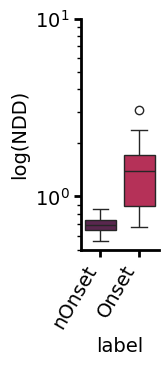

In [ ]:
all_nsoz = []
all_soz = []
# 'LiNDDA_mse_sl1_fl1'
# 'GIN_mse_sl12_fl1'
for _,group in test_data_interrater[test_data_interrater.full_model_key.isin(['LiNDDA_mse_sl5_fl4'])].groupby('patient'):
    all_nsoz.append(group.avg_onset_nsoz_prob.mean())
    all_soz.append(group.avg_onset_soz_prob.mean())
all_nsoz = np.array(all_nsoz)
all_soz = np.array(all_soz)
annot_dataset = pd.concat([pd.DataFrame(np.concatenate((all_nsoz,all_soz),axis=0),columns=['probability']),pd.DataFrame(['nsoz']*len(all_nsoz) + ['soz']*len(all_soz),columns=['label'])],axis=1).dropna()
plt.figure(figsize=(1,3))
plt.xticks([0,1],['nOnset','Onset'],rotation=60,ha='right')
sns.boxplot(annot_dataset,x='label',y='probability',hue='label',palette=sns.color_palette('rocket',n_colors=3)[:2],width=.8,legend=False)
plt.ylabel('log(NDD)')
plt.yscale('log')
plt.ylim([0.5,10])
sns.despine()
print(roc_auc_score(annot_dataset.label,annot_dataset.probability))
plt.savefig(ospj(figpath,'onset_localization.pdf'),bbox_inches='tight',transparent=True)

0.941358024691358


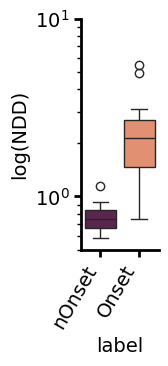

In [ ]:
all_nsoz = []
all_soz = []
# 'LiNDDA_mse_sl1_fl1'
# 'GIN_mse_sl12_fl1'
for _,group in test_data_interrater[test_data_interrater.full_model_key.isin(['LiNDDA_mse_sl5_fl4'])].groupby('patient'):
    all_nsoz.append(group.avg_spread_nsoz_prob.mean())
    all_soz.append(group.avg_spread_soz_prob.mean())
all_nsoz = np.array(all_nsoz)
all_soz = np.array(all_soz)
annot_dataset = pd.concat([pd.DataFrame(np.concatenate((all_nsoz,all_soz),axis=0),columns=['probability']),pd.DataFrame(['nsoz']*len(all_nsoz) + ['soz']*len(all_soz),columns=['label'])],axis=1).dropna()
plt.figure(figsize=(1,3))
plt.xticks([0,1],['nOnset','Onset'],rotation=60,ha='right')
sns.boxplot(annot_dataset,x='label',y='probability',hue='label',palette=sns.color_palette('rocket',n_colors=3)[::2],width=.8,legend=False)
plt.ylabel('log(NDD)')
plt.yscale('log')
plt.ylim([0.5,10])
sns.despine()
print(roc_auc_score(annot_dataset.label,annot_dataset.probability))
plt.savefig(ospj(figpath,'spread_localization.pdf'),bbox_inches='tight',transparent=True)

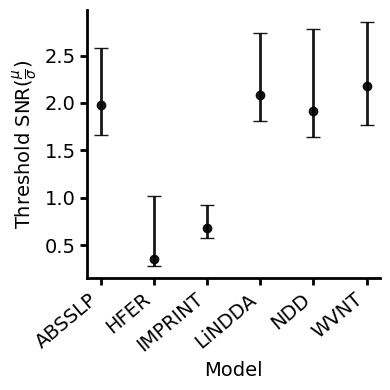

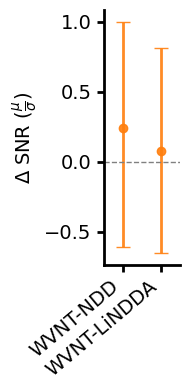

In [939]:
import numpy as np
import matplotlib.pyplot as plt

# Restrict to just test_data (not the interrater-augmented DataFrame)
snr_results = []
n_boot = 1000
rng = np.random.default_rng(42)

for model in test_data['model_name'].unique():
    vals = test_data.loc[
        test_data['model_name'] == model, 'optimal_onset_threshold' if 'optimal_onset_threshold' in test_data.columns else 'phi_at_optimal_threshold'
    ].dropna().values
    if len(vals) < 2:
        continue
    mean = np.nanmean(vals)
    std = np.nanstd(vals, ddof=1)
    if std == 0:
        continue
    snr = mean / std

    # Bootstrap CIs
    snr_boots = []
    for _ in range(n_boot):
        boot = rng.choice(vals, size=len(vals), replace=True)
        boot_mean = np.nanmean(boot)
        boot_std = np.nanstd(boot, ddof=1)
        if boot_std > 0:
            snr_boots.append(boot_mean / boot_std)
    if not snr_boots:
        continue
    ci_lower, ci_upper = np.percentile(snr_boots, [2.5, 97.5])

    snr_results.append({
        'model': model,
        'snr': snr,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'n': len(vals)
    })

snr_df = pd.DataFrame(snr_results)
snr_df = snr_df.sort_values('model')

fig, ax = plt.subplots(figsize=(4, 4))
xvals = np.arange(len(snr_df))
ax.errorbar(
    xvals,
    snr_df['snr'],
    yerr=[snr_df['snr'] - snr_df['ci_lower'], snr_df['ci_upper'] - snr_df['snr']],
    fmt='o',
    capsize=5,
    color='black',
    alpha=0.9,
)
ax.set_xticks(xvals)
ax.set_xticklabels(snr_df['model'], rotation=40, ha='right')
ax.set_xlabel('Model')
ax.set_ylabel('Threshold SNR($\\frac{\mu}{\sigma}$)')
plt.tight_layout()
sns.despine()
plt.savefig(ospj(figpath,'threshold_snr.pdf'),bbox_inches='tight',transparent=True)
plt.show()
# WVNT - NDD and WVNT - LiNDDA SNR median difference bootstrap with CIs

models = snr_df['model'].tolist()
if 'WVNT' in models and 'NDD' in models and 'LiNDDA' in models:
    # For proper bootstrap, get the underlying vals for each model from test_data
    snr_boots_dict = {}
    for model in ['WVNT', 'NDD', 'LiNDDA']:
        vals = test_data.loc[test_data['model_name'] == model, ['optimal_onset_threshold', 'max_onset_phi']].dropna()['optimal_onset_threshold'].values
        if len(vals) < 2:
            snr_boots_dict[model] = []
            continue
        boots = []
        for _ in range(10000):
            boot = rng.choice(vals, size=len(vals), replace=True)
            boot_mean = np.nanmean(boot)
            boot_std = np.nanstd(boot, ddof=1)
            if boot_std > 0:
                boots.append(boot_mean / boot_std)
        snr_boots_dict[model] = np.array(boots)

    # Calculate differences
    diff_WVNT_NDD = snr_boots_dict['WVNT'] - snr_boots_dict['NDD']
    diff_WVNT_LiNDDA = snr_boots_dict['WVNT'] - snr_boots_dict['LiNDDA']

    # Get medians and bootstrap CIs
    median_diff_WVNT_NDD = np.median(diff_WVNT_NDD)
    ci_WN = np.percentile(diff_WVNT_NDD, [2.5, 97.5])
    median_diff_WVNT_LiNDDA = np.median(diff_WVNT_LiNDDA)
    ci_WL = np.percentile(diff_WVNT_LiNDDA, [2.5, 97.5])

    fig, ax = plt.subplots(figsize=(2, 4))
    diff_medians = [median_diff_WVNT_NDD, median_diff_WVNT_LiNDDA]
    err_lower = [median_diff_WVNT_NDD - ci_WN[0], median_diff_WVNT_LiNDDA - ci_WL[0]]
    err_upper = [ci_WN[1] - median_diff_WVNT_NDD, ci_WL[1] - median_diff_WVNT_LiNDDA]
    ax.errorbar(
        ['WVNT-NDD', 'WVNT-LiNDDA'],
        diff_medians,
        yerr=[err_lower, err_upper],
        fmt='o',
        capsize=5,
        color='C1',
        alpha=0.9,
    )
    plt.xlim([-0.5,1.5])
    plt.xticks([0,1],['WVNT-NDD', 'WVNT-LiNDDA'],rotation=40,ha='right')
    ax.axhline(0, ls='--', c='gray', lw=1)
    ax.set_ylabel('$\Delta$ SNR ($\\frac{\mu}{\sigma}$)')
    plt.tight_layout()
    sns.despine()
    plt.savefig(ospj(figpath,'threshold_snr_diff.pdf'),bbox_inches='tight',transparent=True)
    plt.show()

## Visualization

In [371]:
onset_annots = pd.read_pickle(ospj(prodatapath,'threshold_tuning_consensus_v2.pkl'))
onset_annots = onset_annots[onset_annots.stim == 0]
onset_annots['ueo_channels'] = onset_annots.apply(lambda x: np.array(x.all_chs)[x.ueo_consensus],axis=1)

In [589]:
# test_mat = pd.read_pickle(ospj(prodatapath,'sz_prob/HUP224/HUP224_task-ictal339143_run-00_mdl-ABSSLP_sz_prob.pkl'))

# test_mat = pd.read_pickle(ospj(prodatapath,'sz_prob/HUP238/HUP238_task-ictal290006_run-00_mdl-HFER_sz_prob.pkl'))

# test_mat = pd.read_pickle(ospj(prodatapath,'sz_prob/HUP224/HUP224_task-ictal339143_mdl-LiNDDA_seq-1_mse_prob_forecast-1.pkl'))

test_mat = pd.read_pickle('/Users/wojemann/local_data/dynasd_data/PROCESSED_DATA/sz_prob/HUP238/HUP238_task-ictal290006_mdl-LiNDDA_seq-5_mse_prob_forecast-4.pkl')
prob_times = test_mat.pop('time')
onset_idx = np.argmin(np.abs(prob_times-180))
sz_onset_annot = onset_annots.loc[(onset_annots.patient == 'HUP224') & ((onset_annots.approximate_onset - 339143) < 120)]
onset_chs =np.array([ch[0] in sz_onset_annot.ueo_channels.iloc[0] for ch in test_mat.columns.str.split('-')])
# test_mat /= 100

In [590]:
# print(onset_idx)
# test_mat.loc[310:365,['LC01-LC02']]

In [591]:
test_mat.columns[np.argwhere((test_mat.loc[360:365,:]>1.163061534).sum()>4)[:,0]]
test_mat.columns[np.argwhere((test_mat.loc[360:365,:].median()>1.163061534))[:,0]]

Index(['LB01-LB02', 'LB02-LB03', 'LC01-LC02', 'LC02-LC03', 'LC03-LC04'], dtype='object')

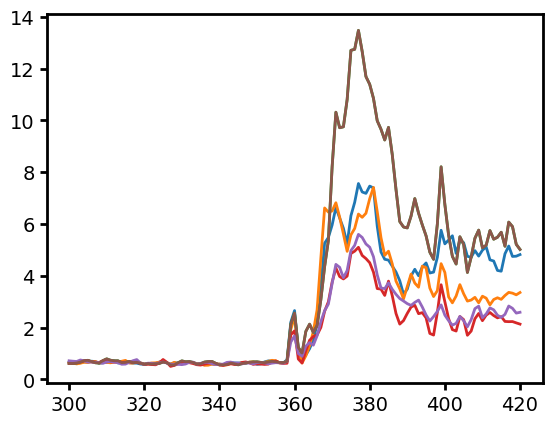

In [592]:
plt.plot(test_mat.loc[300:420,test_mat.columns[np.argwhere((test_mat.loc[360:365,:].median()>1.163061534))[:,0]].to_list()+['LC01-LC02']])
# plt.legend(test_mat.columns[np.argwhere((test_mat.loc[360:365,:].median()>1.163061534))[:,0]].to_list()+['LC01-LC02'])

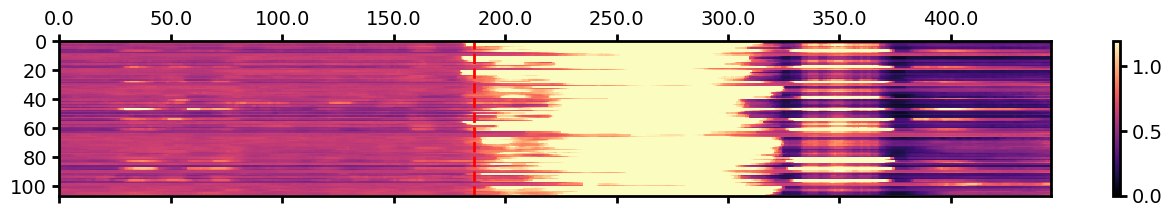

In [595]:
plt.matshow(sc.ndimage.median_filter(test_mat.T,20,axes=1),aspect='auto',cmap='magma',
clim=(0,1.2)
)

plt.xticks(ticks=np.arange(0, len(prob_times), 100), labels=prob_times.to_numpy()[::100].round(0))
onset_idx = np.argmin(np.abs(prob_times-186))
plt.axvline(onset_idx,linestyle='--',color='red')
plt.colorbar()
plt.show()


In [19]:
onset_idx

366